#  Exploratory Data Analysis (EDA) on Titanic Dataset
## Introduction
This project performs Exploratory Data Analysis (EDA) on the Titanic dataset to understand patterns and factors affecting passenger survival.

We analyze features such as age, gender, passenger class, and fare to identify trends and relationships.


#### 1. import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

#### 2. Load Dataset

In [2]:
df = pd.read_csv("Titanic_Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### 3. Data Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.drop('Cabin', axis=1, inplace=True)
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

- The dataset contains missing values in Age, Cabin, and Embarked columns.
- Cabin has a large number of missing values, so it may not be useful.

### 4. Data Cleaning and preprocessing

In [6]:
# Drop useless columns
df.drop(['Name', 'Ticket'], axis=1, inplace=True)

# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encode categorical data
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

C:\Users\anees\AppData\Local\Temp\ipykernel_6500\3873919080.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\anees\AppData\Local\Temp\ipykernel_6500\3873919080.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

### 5. Converting to categorical data

In [7]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2})

- Missing values were handled using mean and mode.
- Cabin column was removed due to excessive missing data.
- Categorical variables were converted into numeric for analysis.

### 6. Feature Engineering


In [8]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

##### Creating age groups

In [9]:
df['AgeGroup'] = pd.cut(df['Age'],
                       bins=[0,12,20,40,60,100],
                       labels=['Child','Teen','Adult','Middle Age','Senior'])

#### 7. Data Visualization

##### Survival Distribuition

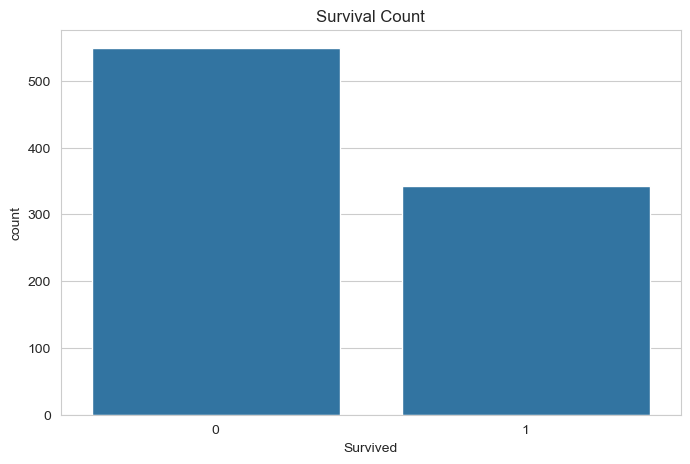

In [10]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

##### Gender vs Survival

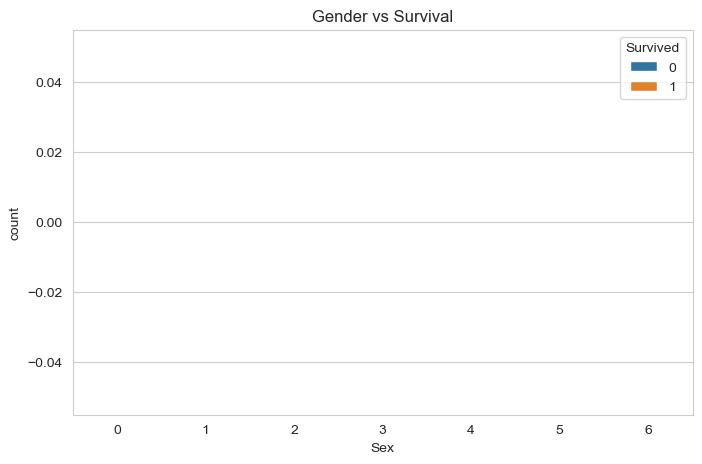

In [11]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Gender vs Survival")
plt.show()

##### Class vs Survival

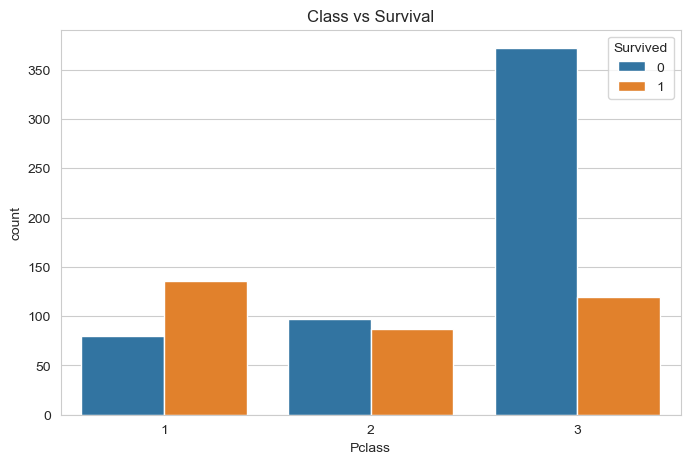

In [12]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Class vs Survival")
plt.show()

##### Age Distribution

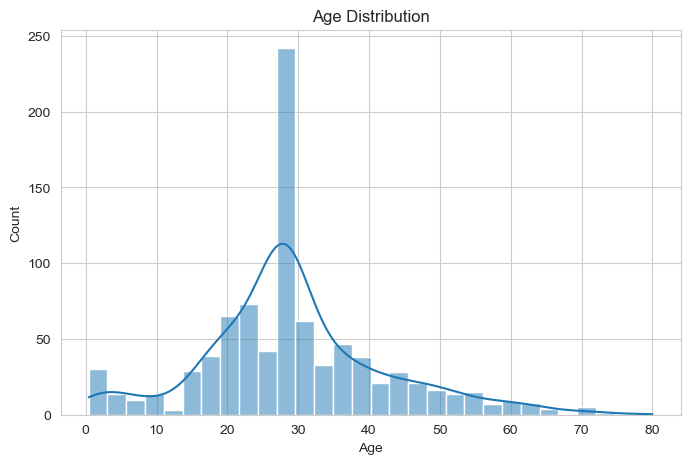

In [13]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

##### Family vs Survival

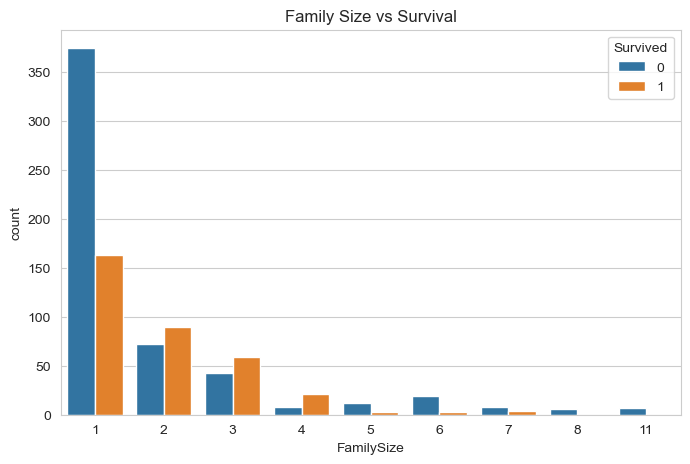

In [14]:
sns.countplot(x='FamilySize', hue='Survived', data=df)
plt.title("Family Size vs Survival")
plt.show()

##### Fare vs Survival

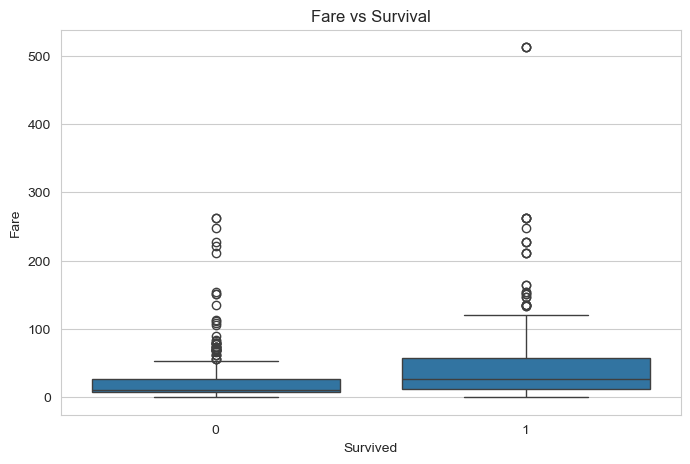

In [15]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare vs Survival")
plt.show()

##### Corelation Heatmap

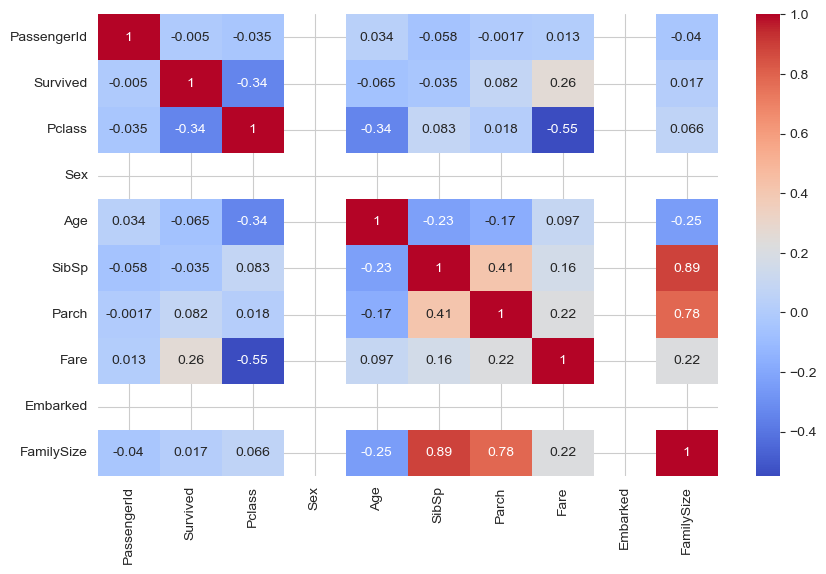

In [16]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

#### 8. Key Observations


- Women had a much higher survival rate than men.
- First-class passengers survived more than lower classes.
- Higher fare increased chances of survival.
- Small families had better survival probability.
- Age had less impact compared to gender and class.

### Conclusion

Survival on the Titanic was influenced mainly by gender, passenger class, and fare. Women and higher-class passengers had significantly better survival chances. Feature engineering like family size helped uncover additional patterns.